In [1]:
import numpy as np
import pandas as pd
import joblib

In [23]:
!pip install mlxtend


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.2 MB/s eta 0:00:00a 0:00:01


In [24]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori

# Einstellungen

In [4]:
# Diese Variable entscheidet, ob die zusammengeführte Tabelle neu aggregiert werden soll. Falls Ture wird die aggregated_train.parquet Datei neu generiert.
# Dafür wird es vermutlich nicht mehr oft einen Grund geben.
neu_aggregiren = False

# Datengrundlage erstellen

In [5]:
products_source = pd.read_csv('data/products.csv')
stores_source   = pd.read_csv('data/stores.csv')
transaction_lines_test_source   = pd.read_parquet('data/transaction_lines_test_1.parquet')
transaction_lines_train_source  = pd.read_parquet('data/transaction_lines_train_1.parquet')
transactions_test_source        = pd.read_parquet('data/transactions_test_1.parquet')
transactions_train_source       = pd.read_parquet('data/transactions_train_1.parquet')


In [6]:
if neu_aggregiren:
    transactions_enriched = pd.merge(
        transactions_train_source,
        stores_source,
        left_on='store_id',
        right_on='id',
        how='left',
        suffixes=('', '_store')
    )
    # Drop the redundant 'id' column from the stores table after merge
    transactions_enriched = transactions_enriched.drop(columns=['id_store'], errors='ignore')

In [7]:
if neu_aggregiren:
    lines_enriched = pd.merge(
        transaction_lines_train_source,
        products_source,
        left_on='product_id',
        right_on='id',
        how='left',
        suffixes=('', '_product')
    )
    # Drop the redundant 'id' column from the products table after merge
    lines_enriched = lines_enriched.drop(columns=['id_product'], errors='ignore')

# Merged Tabelle Generieren

In [8]:
# Group the enriched lines by transaction_id
# For each group, convert the rows (which are lines for that transaction)
# into a list of dictionaries.
# Using apply with lambda is a common way to do this.
# Using .to_dict('records') converts the DataFrame group into List[Dict]
if neu_aggregiren:
    aggregated_lines = lines_enriched.groupby('transaction_id').apply(
        lambda x: x.to_dict('records'),
        # include_groups=False # For newer pandas versions to avoid warning/error
    ).reset_index(name='transaction_lines_details')

    print("Aggregated lines structure (first few):")
    print(aggregated_lines.head())

In [9]:
# Merge the aggregated lines back onto the enriched transactions table
# Key for transactions_enriched is 'id' (transaction ID)
# Key for aggregated_lines is 'transaction_id'
if neu_aggregiren:
    transactions_for_pipeline = pd.merge(
        transactions_enriched,
        aggregated_lines,
        left_on='id',           # Transaction ID from the main transactions table
        right_on='transaction_id', # Transaction ID from the aggregated lines
        how='left'              # Keep all transactions, add lines where they exist
    )

    # Drop the now redundant 'transaction_id' column that came from aggregated_lines
    transactions_for_pipeline = transactions_for_pipeline.drop(columns=['transaction_id'])
    # Save the file
    transactions_for_pipeline.to_parquet('data/aggregated_train.parquet')
else:
    transactions_for_pipeline = pd.read_parquet('data/aggregated_train.parquet')

transactions_for_pipeline

,id,store_id,cash_desk,transaction_start,transaction_end,total_amount,n_lines,payment_medium,customer_feedback,damage,label,opening_date,location,state,urbanization,sco_introduction,transaction_lines_details
0,5bedf771-f016-41a7-ab89-f40e7f6be955,b0973ffa-ce15-41e0-9de7-1390598e24f2,0,2022-02-02 08:00:12.000000,2022-02-02 08:01:02.825563,52.26,6,CREDIT_CARD,NaN,NaN,UNKNOWN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
1,21ff1406-dbc4-41a7-8429-836cbf96d853,b0973ffa-ce15-41e0-9de7-1390598e24f2,1,2022-02-02 08:05:06.000000,2022-02-02 08:05:30.565876,1.47,1,CREDIT_CARD,NaN,NaN,UNKNOWN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
2,b642f9b6-43b5-413d-ad08-b4bf4b664b52,b0973ffa-ce15-41e0-9de7-1390598e24f2,2,2022-02-02 08:07:12.000000,2022-02-02 08:11:29.434607,363.87,37,CREDIT_CARD,NaN,0.0,NORMAL,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
3,16aa01c9-9678-4c6d-a007-baa3429b9fb8,b0973ffa-ce15-41e0-9de7-1390598e24f2,3,2022-02-02 08:11:45.000000,2022-02-02 08:12:07.881710,3.43,1,CREDIT_CARD,NaN,NaN,UNKNOWN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
4,0add22e5-6794-4e95-9d25-a1cd6b6cd083,b0973ffa-ce15-41e0-9de7-1390598e24f2,0,2022-02-02 08:15:15.000000,2022-02-02 08:19:30.611551,441.40,47,CREDIT_CARD,NaN,NaN,UNKNOWN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558240,703518b6-435c-4665-84a9-35b914d27f12,ed996b17-17d6-47e8-9262-d1d02b52cdb4,1,2023-12-30 21:57:13.359949,2023-12-30 21:58:17.045461,117.47,6,CREDIT_CARD,10.0,NaN,UNKNOWN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558241,1aae20ce-f7a4-4dd0-a1f7-ab580cc81c7d,ed996b17-17d6-47e8-9262-d1d02b52cdb4,0,2023-12-30 21:57:24.000000,2023-12-30 21:58:44.201062,76.79,6,CREDIT_CARD,NaN,NaN,UNKNOWN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558242,dc62b127-ccd0-455d-8dc8-99fe63a9e6cb,ed996b17-17d6-47e8-9262-d1d02b52cdb4,3,2023-12-30 21:57:45.000000,2023-12-30 22:00:28.962767,237.00,23,CREDIT_CARD,NaN,NaN,UNKNOWN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558243,e3004e7e-452a-407d-9a84-84d3b797a422,ed996b17-17d6-47e8-9262-d1d02b52cdb4,2,2023-12-30 21:58:06.000000,2023-12-30 22:00:08.294801,126.99,19,CREDIT_CARD,NaN,NaN,UNKNOWN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."


In [10]:
transactions_for_pipeline = transactions_for_pipeline[transactions_for_pipeline['label'] != 'UNKNOWN']


In [11]:
transactions_for_pipeline.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155692 entries, 2 to 1558199
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id                         155692 non-null  object        
 1   store_id                   155692 non-null  object        
 2   cash_desk                  155692 non-null  int64         
 3   transaction_start          155692 non-null  datetime64[us]
 4   transaction_end            155692 non-null  datetime64[us]
 5   total_amount               155692 non-null  float64       
 6   n_lines                    155692 non-null  int64         
 7   payment_medium             155692 non-null  object        
 8   customer_feedback          10641 non-null   float64       
 9   damage                     155692 non-null  float64       
 10  label                      155692 non-null  object        
 11  opening_date               155692 non-null  object      

# Generator Klassen

In diesem Abschnitt definieren wir benutzerdefinierte Transformer-Klassen, die von `BaseEstimator` und `TransformerMixin` aus Scikit-learn erben. Diese Klassen kapseln spezifische Logiken zur Feature-Erstellung und -Transformation und können nahtlos in Scikit-learn Pipelines integriert werden. Dies fördert die Wiederverwendbarkeit und Strukturierung des Feature-Engineering-Prozesses.

- `TimeFeatureGenerator`: Extrahiert diverse zeitbasierte Merkmale aus Zeitstempelspalten (`transaction_start`, `transaction_end`). Dazu gehören einfache Zeiteinheiten, zyklische Transformationen (Sinus/Kosinus), binäre Indikatoren und Interaktionsmerkmale.
- `FeedbackBinnerOHE`: Verarbeitet die `customer_feedback`-Spalte. Fehlende Werte und spezifische Werte (z.B. 10.0) werden in diskrete Kategorien eingeteilt, welche anschließend mittels One-Hot-Encoding in numerische Features umgewandelt werden.

Beide Transformer implementieren die Methoden `fit`, `transform` und `get_feature_names_out`, um eine korrekte Integration in den `ColumnTransformer` von Scikit-learn zu gewährleisten.

In [12]:
class TimeFeatureGenerator(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass # Keine Initialisierungsparameter notwendig

    def fit(self, X, y=None):
        # Dieser Transformer lernt keine Parameter aus den Daten.
        return self

    def transform(self, X, y=None):
        # Eingabe X: DataFrame mit 'transaction_start' und 'transaction_end'
        df_transformed = pd.DataFrame(index=X.index) # Erstellt eine Kopie mit dem ursprünglichen Index

        transaction_start = pd.to_datetime(X['transaction_start'])
        transaction_end = pd.to_datetime(X['transaction_end'])

        # --- Basis-Zeitmerkmale ---
        df_transformed['ft_month'] = transaction_start.dt.month
        df_transformed['ft_day'] = transaction_start.dt.day
        
        duration = transaction_end - transaction_start
        ft_duration_seconds_val = duration.dt.total_seconds()

        # --- Zyklische Zeit-basierte Features (aus transaction_start) ---
        df_transformed['ft_hour'] = transaction_start.dt.hour
        df_transformed['ft_minute'] = transaction_start.dt.minute
        df_transformed['ft_second'] = transaction_start.dt.second
        df_transformed['ft_day_of_week'] = transaction_start.dt.dayofweek # Montag=0, Sonntag=6
        df_transformed['ft_day_of_year'] = transaction_start.dt.dayofyear
        df_transformed['ft_week_of_year'] = transaction_start.dt.isocalendar().week.astype(int) # .week kann nullable sein
        df_transformed['ft_quarter'] = transaction_start.dt.quarter

        # --- Binäre/ereignisbasierte Features ---
        df_transformed['ft_is_weekend'] = df_transformed['ft_day_of_week'].isin([5, 6]).astype(int) # Samstag=5, Sonntag=6
        # Annahme: Normale Stunden sind 08:00 - 22:59 Uhr
        df_transformed['ft_is_outside_normal_hours'] = \
            ((df_transformed['ft_hour'] < 8) | (df_transformed['ft_hour'] >= 23)).astype(int)

        # --- Kodierung zyklischer Features (Sinus/Kosinus Transformation) ---
        df_transformed['ft_month_sin'] = np.sin(2 * np.pi * df_transformed['ft_month']/12)
        df_transformed['ft_month_cos'] = np.cos(2 * np.pi * df_transformed['ft_month']/12)

        df_transformed['ft_hour_sin'] = np.sin(2 * np.pi * df_transformed['ft_hour']/24)
        df_transformed['ft_hour_cos'] = np.cos(2 * np.pi * df_transformed['ft_hour']/24)

        df_transformed['ft_day_of_week_sin'] = np.sin(2 * np.pi * df_transformed['ft_day_of_week']/7)
        df_transformed['ft_day_of_week_cos'] = np.cos(2 * np.pi * df_transformed['ft_day_of_week']/7)

        days_in_year = transaction_start.dt.is_leap_year.map({True: 366, False: 365})
        df_transformed['ft_day_of_year_sin'] = np.sin(2 * np.pi * df_transformed['ft_day_of_year']/days_in_year)
        df_transformed['ft_day_of_year_cos'] = np.cos(2 * np.pi * df_transformed['ft_day_of_year']/days_in_year)
        
        # --- Transformation für ft_duration_seconds ---
        # Log-Transformation (np.log1p für Stabilität bei Werten nahe 0)
        df_transformed['ft_duration_seconds_log'] = np.log1p(ft_duration_seconds_val)

        # --- Interaktionsmerkmale ---
        df_transformed['ft_inter_weekend_outside_hours'] = \
            df_transformed['ft_is_weekend'] * df_transformed['ft_is_outside_normal_hours']
        df_transformed['ft_inter_hour_cos_x_dow_cos'] = \
            df_transformed['ft_hour_cos'] * df_transformed['ft_day_of_week_cos']
            
        # Speichert die Namen der generierten Features für get_feature_names_out.
        # Die Reihenfolge muss der Erstellung der Spalten entsprechen.
        self.feature_names_out_ = [
            'ft_month', 'ft_day', 
            'ft_hour', 'ft_minute', 'ft_second', 
            'ft_day_of_week', 'ft_day_of_year', 'ft_week_of_year', 'ft_quarter',
            'ft_is_weekend', 'ft_is_outside_normal_hours',
            'ft_month_sin', 'ft_month_cos',
            'ft_hour_sin', 'ft_hour_cos',
            'ft_day_of_week_sin', 'ft_day_of_week_cos',
            'ft_day_of_year_sin', 'ft_day_of_year_cos',
            'ft_duration_seconds_log', # Log-transformierte Dauer
            'ft_inter_weekend_outside_hours',
            'ft_inter_hour_cos_x_dow_cos'
        ]
        
        return df_transformed[self.feature_names_out_]

    def get_feature_names_out(self, input_features=None):
        # Gibt die Namen der erzeugten Features zurück.
        return self.feature_names_out_

In [13]:
class FeedbackBinnerOHE(BaseEstimator, TransformerMixin):
    """
    Benutzerdefinierter Transformer für die 'customer_feedback'-Spalte.
    1. Kategorisiert Feedback-Werte ('feedback_null', 'feedback_10', 'feedback_other').
    2. Führt One-Hot-Encoding für diese Kategorien durch (Präfix 'ft_').
    """
    def __init__(self):
        # Feste Kategorien und daraus resultierende Feature-Namen.
        self.categories_ = ['feedback_null', 'feedback_10', 'feedback_other']
        self.feature_names_out_ = [f"ft_{cat}" for cat in self.categories_]

    def fit(self, X, y=None):
        # Keine Anpassung an die Daten nötig, da Kategorien vordefiniert sind.
        return self

    def _categorize_feedback(self, feedback_value):
        # Interne Hilfsfunktion zur Kategorisierung.
        if pd.isnull(feedback_value):
            return 'feedback_null'
        elif feedback_value == 10.0:
            return 'feedback_10'
        else:  # Alle anderen nicht-null Werte (z.B. 1.0 bis 9.0)
            return 'feedback_other'

    def transform(self, X, y=None):
        # Eingabe X: DataFrame mit der 'customer_feedback'-Spalte.
        feedback_series = X.iloc[:, 0] # Extrahiert die relevante Spalte als Series.
        
        # Anwenden der Kategorisierungsfunktion.
        categorized_feedback = feedback_series.apply(self._categorize_feedback)
        
        # One-Hot-Encoding.
        # pd.Categorical stellt sicher, dass alle definierten Kategorien als Spalten erscheinen.
        categorized_feedback_type = pd.Categorical(categorized_feedback, categories=self.categories_)
        dummies_df = pd.get_dummies(categorized_feedback_type, prefix='ft', dtype=int)
        
        return dummies_df[self.feature_names_out_] # Gibt DataFrame mit Dummy-Variablen zurück.

    def get_feature_names_out(self, input_features=None):
        # Gibt die Namen der erzeugten Features zurück.
        return self.feature_names_out_

In [32]:
class TransactionLineFeatures(BaseEstimator, TransformerMixin):
    """
    Custom transformer for 'transaction_lines_details'.
    Calculates average and median 'price' from transaction lines.
    """
    def __init__(self):
        self.feature_names_out_ = ['ft_avg_line_price', 'ft_median_line_price']

    def fit(self, X, y=None):
        # No fitting needed for this transformer
        return self

    def _calculate_stats(self, transaction_lines):
        # Helper function to calculate stats for a single transaction's lines
        if isinstance(transaction_lines, (list, np.ndarray)) and len(transaction_lines) > 0:
            prices = [line.get('price') for line in transaction_lines if isinstance(line, dict) and line.get('price') is not None]
            if prices:
                return np.mean(prices), np.median(prices)
        return np.nan, np.nan # Return NaN if no valid prices are found or input is not as expected

    def transform(self, X, y=None):
        # X is expected to be a DataFrame with the 'transaction_lines_details' column
        # Ensure X is a DataFrame, as ColumnTransformer might pass a Series
        if isinstance(X, pd.Series):
            X_df = X.to_frame()
        elif isinstance(X, np.ndarray): # If it's a numpy array, convert to DataFrame
            X_df = pd.DataFrame(X, columns=['transaction_lines_details'])
        else:
            X_df = X.copy()


        # Apply the calculation row-wise
        stats = X_df.iloc[:, 0].apply(self._calculate_stats)

        # Create a DataFrame with the new features
        df_transformed = pd.DataFrame(stats.tolist(), index=X_df.index, columns=self.feature_names_out_)

        # Handle potential NaNs from calculations by filling them, e.g., with 0 or mean/median of the new columns
        # For simplicity, let's fill with 0 here, but you might choose a different strategy
        df_transformed.fillna(0, inplace=True)

        return df_transformed

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

In [33]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class TransactionLineFeatures(BaseEstimator, TransformerMixin):
    """
    Custom transformer for 'transaction_lines_details'.
    Berechnet aggregierte Features aus jeder Transaktionszeile (Produktdaten), um verdächtige Muster für Fraud-Erkennung zu identifizieren.
    Die Features werden transaktionsweise berechnet und können direkt in ML-Pipelines verwendet werden.

    **Ziel des maschinellen Lernens:**
    - **Fraud-Erkennung:** Vorhersage, ob eine Transaktion "FRAUD" (Betrug) oder "NORMAL" ist.
    - **Signalstärke:** Die konstruierten Features sollen verdächtige Muster (z.B. Preisabweichungen, häufige Stornierungen, ungewöhnliche Rabatte) verstärken, damit das ML-Modell sie besser erkennen kann.
    """

    def __init__(self):
        # Liste der Feature-Namen, die berechnet werden
        self.feature_names_out_ = [
            'ft_avg_line_price',               # Durchschnittlicher Listenpreis pro Transaktion
            'ft_median_line_price',            # Median-Preis pro Transaktion
            'ft_avg_discount_ratio',           # Durchschnittlicher Rabattanteil pro Transaktion
            'ft_avg_price_delta',              # Durchschnittliche Abweichung zwischen Preis und erwartetem Preis
            'ft_avg_unit_price_deviation',     # Durchschnittliche Abweichung des Einzelpreises vom Kategoriendurchschnitt
            'ft_frac_high_risk',               # Anteil der Hochrisiko-Artikel pro Transaktion
            'ft_frac_voided',                  # Anteil der stornierten Artikel pro Transaktion
            'ft_frac_age_restricted',          # Anteil der altersbeschränkten Artikel pro Transaktion
            'ft_frac_zero_weight',             # Anteil der Artikel mit Gewicht = 0 (unplausibel)
            'ft_avg_popularity_deviation'      # Durchschnittliche Abweichung der Popularität vom Transaktionsdurchschnitt
        ]
        # Definition der Hochrisiko-Kategorien (kann angepasst werden)
        self.high_risk_categories = {'Alcohol', 'Tobacco', 'Electronics'}

    def fit(self, X, y=None):
        """
        Keine Anpassung nötig, da wir keine globalen Parameter lernen.
        """
        return self

    def _calculate_features(self, transaction_lines):
        """
        Berechnet für eine Liste von Produktzeilen (eine Transaktion) alle relevanten Features.
        :param transaction_lines: Liste von Dictionaries mit Produktdaten
        :return: Liste der berechneten Features (in Reihenfolge von feature_names_out_)
        """
        if not isinstance(transaction_lines, (list, np.ndarray)) or len(transaction_lines) == 0:
            # Keine Daten → alle Features auf NaN
            return [np.nan] * len(self.feature_names_out_)

        # Konvertiere die Liste in einen DataFrame für einfache Berechnungen
        lines = pd.DataFrame([line for line in transaction_lines if isinstance(line, dict)])
        n = len(lines)
        if n == 0:
            return [np.nan] * len(self.feature_names_out_)

        # 1. Durchschnittlicher und Median-Preis pro Transaktion
        # **Warum:** Ungewöhnlich hohe oder niedrige Preise können auf Betrug hinweisen.
        prices = lines['price'].dropna()
        avg_price = prices.mean() if not prices.empty else np.nan
        median_price = prices.median() if not prices.empty else np.nan

        # 2. Durchschnittlicher Rabattanteil pro Transaktion
        # **Warum:** Ungewöhnlich hohe Rabatte sind ein klassisches Betrugssignal.
        if 'discount_amount' in lines and 'price' in lines:
            discount_ratio = (lines['discount_amount'] / lines['price']).replace([np.inf, -np.inf], np.nan)
            avg_discount_ratio = discount_ratio.mean()
        else:
            avg_discount_ratio = np.nan

        # 3. Durchschnittliche Abweichung zwischen Preis und erwartetem Preis
        # **Warum:** Wenn jemand deutlich weniger zahlt als erwartet, ist das verdächtig.
        if 'expected_price' in lines and 'price' in lines:
            price_delta = (lines['price'] - lines['expected_price']).replace([np.inf, -np.inf], np.nan)
            avg_price_delta = price_delta.mean()
        else:
            avg_price_delta = np.nan

        # 4. Durchschnittliche Abweichung des Einzelpreises vom Kategoriendurchschnitt
        # **Warum:** Ungewöhnliche Einzelpreise (z.B. 1kg Äpfel zu 0.5€/kg statt 2.99€/kg) sind ein Fraud-Signal.
        if 'price_per_unit' in lines and 'category' in lines:
            cat_means = lines.groupby('category')['price_per_unit'].transform('mean')
            unit_price_deviation = (lines['price_per_unit'] - cat_means).abs()
            avg_unit_price_deviation = unit_price_deviation.mean()
        else:
            avg_unit_price_deviation = np.nan

        # 5. Anteil der Hochrisiko-Artikel pro Transaktion
        # **Warum:** Bestimmte Kategorien (z.B. Alkohol, Elektronik) werden häufiger gestohlen.
        if 'category' in lines:
            frac_high_risk = lines['category'].isin(self.high_risk_categories).mean()
        else:
            frac_high_risk = np.nan

        # 6. Anteil der stornierten Artikel pro Transaktion
        # **Warum:** Häufige Stornierungen sind ein starkes Fraud-Signal.
        if 'was_voided' in lines:
            frac_voided = lines['was_voided'].astype(float).mean()
        else:
            frac_voided = np.nan

        # 7. Anteil der altersbeschränkten Artikel pro Transaktion
        # **Warum:** Transaktionen mit altersbeschränkten Artikeln sind seltener Fraud (wichtiger Negativ-Indikator).
        if 'age_restricted' in lines:
            frac_age_restricted = lines['age_restricted'].astype(float).mean()
        else:
            frac_age_restricted = np.nan

        # 8. Anteil der Artikel mit Gewicht = 0 (unplausibel)
        # **Warum:** Gewicht = 0 bei Stückware ist unplausibel und kann auf Fehler oder Betrug hinweisen.
        if 'weight' in lines:
            frac_zero_weight = (lines['weight'] == 0).mean()
        else:
            frac_zero_weight = np.nan

        # 9. Durchschnittliche Abweichung der Popularität vom Transaktionsdurchschnitt
        # **Warum:** Seltene Artikel (niedrige Popularität) werden öfter gestohlen oder falsch gescannt.
        if 'popularity' in lines:
            avg_popularity_deviation = (lines['popularity'] - lines['popularity'].mean()).abs().mean()
        else:
            avg_popularity_deviation = np.nan

        return [
            avg_price,
            median_price,
            avg_discount_ratio,
            avg_price_delta,
            avg_unit_price_deviation,
            frac_high_risk,
            frac_voided,
            frac_age_restricted,
            frac_zero_weight,
            avg_popularity_deviation
        ]

    def transform(self, X, y=None):
        """
        Transformiert den DataFrame mit 'transaction_lines_details' in einen DataFrame mit den berechneten Features.
        :param X: DataFrame mit der Spalte 'transaction_lines_details'
        :param y: Optional, nicht benötigt
        :return: DataFrame mit den berechneten Features
        """
        if isinstance(X, pd.Series):
            X_df = X.to_frame()
        elif isinstance(X, np.ndarray):
            X_df = pd.DataFrame(X, columns=['transaction_lines_details'])
        else:
            X_df = X.copy()

        # Berechne für jede Zeile die Features
        stats = X_df.iloc[:, 0].apply(self._calculate_features)

        # Erstelle einen DataFrame mit den neuen Features
        df_transformed = pd.DataFrame(stats.tolist(), index=X_df.index, columns=self.feature_names_out_)

        # Ersetze NaN durch 0 (kann je nach Anwendungsfall angepasst werden)
        df_transformed.fillna(0, inplace=True)

        return df_transformed

    def get_feature_names_out(self, input_features=None):
        """
        Gibt die Namen der berechneten Features zurück.
        :param input_features: Nicht benötigt
        :return: Liste der Feature-Namen
        """
        return self.feature_names_out_


Zusammenfassung: Warum machen wir das?
Ziel des maschinellen Lernens:
Wir wollen ein Modell trainieren, das automatisch erkennt, ob eine Supermarkt-Transaktion an der Self-Checkout-Kasse betrügerisch ("FRAUD") oder normal ("NORMAL") ist.

Warum Feature-Engineering?

Rohdaten sind schwer zu interpretieren:
Die ursprünglichen Transaktionsdaten sind für ein ML-Modell schwer verständlich (z.B. Listen von Produkten, viele Details).

Signale verstärken:
Durch gezielte Berechnung von Features wie Rabattanteil, Preisabweichung, Anteil stornierter Artikel usw. machen wir verdächtige Muster für das Modell sichtbar.

Domain-Wissen einbauen:
Wir nutzen unser Wissen über typische Betrugsmuster (z.B. häufige Stornierungen, ungewöhnliche Rabatte, Hochrisiko-Artikel) und übersetzen es in messbare Merkmale.

Vorteile:

Modell kann besser lernen:
Das Modell erkennt Muster schneller und zuverlässiger, wenn die Features gut gewählt sind.

Interpretierbarkeit:
Die berechneten Features sind für Menschen und Maschinen verständlich und können später erklärt werden.

In [34]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class EnhancedTransactionLineFeatures(BaseEstimator, TransformerMixin):
    """
    Erweiterte Feature-Engineering-Klasse für Transaction-Lines.
    Berechnet zahlreiche verdächtige Muster für Fraud-Erkennung an Self-Checkout-Kassen.
    Die Features werden aus den Produktdetails jeder Transaktion berechnet und aggregiert.
    Ziel: Verdächtige Transaktionen (z.B. Preisabweichungen, häufige Stornierungen, ungewöhnliche Rabatte)
          für ML-Modelle sichtbar machen.
    """

    def __init__(self):
        # Liste der Ausgabe-Features, die berechnet werden
        self.feature_names_out_ = [
            # Pricing & Discounts
            'ft_avg_discount_ratio',         # Durchschnittlicher Rabattanteil pro Transaktion
            'ft_max_price_delta',            # Maximale Abweichung zwischen Preis und erwartetem Preis
            'ft_unit_price_deviation',       # Durchschnittliche Abweichung des Einzelpreises vom Kategoriendurchschnitt
            
            # Product Classifications
            'ft_high_risk_ratio',            # Anteil der Hochrisikokategorie-Artikel pro Transaktion
            'ft_luxury_item_count',          # Anzahl der Luxusartikel pro Transaktion
            
            # Weight & Quantity
            'ft_weight_discrepancy',         # Durchschnittliche Abweichung des Gewichts vom erwarteten Gewicht
            'ft_zero_weight_ratio',          # Anteil der Artikel mit Gewicht = 0
            
            # Age Restrictions
            'ft_mixed_age_flag',             # Transaktion enthält sowohl altersbeschränkte als auch nicht-altersbeschränkte Artikel
            'ft_missing_age_restriction',    # Anteil der Hochrisikoartikel ohne Alterskennzeichnung
            
            # Void Patterns
            'ft_void_time_variance',         # Varianz der Zeit zwischen Scan und Storno (wenn vorhanden)
            'ft_void_high_risk_ratio',       # Anteil der stornierten Hochrisikoartikel
            
            # Popularity & Newness
            'ft_popularity_deviation',       # Durchschnittliche Abweichung der Popularität vom Transaktionsdurchschnitt
            'ft_new_product_ratio'           # Anteil der neu eingeführten Produkte
        ]
        
        # Konfigurierbare Parameter
        self.high_risk_categories = {'Alcohol', 'Tobacco', 'Electronics'}
        self.luxury_price_threshold = 50  # Euro, ab diesem Preis gilt ein Artikel als Luxusartikel
        self.new_product_days = 30        # Tage, ab wann ein Produkt nicht mehr als "neu" gilt

    def fit(self, X, y=None):
        # Kein Training nötig, da keine globalen Parameter gelernt werden
        return self

    def _calculate_features(self, transaction_lines):
        """
        Berechnet die Features für eine Liste von Produktzeilen (eine Transaktion).
        """
        if not isinstance(transaction_lines, (list, np.ndarray)) or len(transaction_lines) == 0:
            return [np.nan] * len(self.feature_names_out_)

        # Konvertiere die Liste in einen DataFrame für einfache Berechnungen
        lines = pd.DataFrame([line for line in transaction_lines if isinstance(line, dict)])
        if lines.empty:
            return [np.nan] * len(self.feature_names_out_)

        features = []
        
        # A) Pricing & Discounts
        # Durchschnittlicher Rabattanteil pro Transaktion
        discount_ratio = lines['discount_amount'] / lines['price']
        features.append(discount_ratio.mean())
        # Maximale Abweichung zwischen Preis und erwartetem Preis
        features.append((lines['price'] - lines['expected_price']).max())
        # Durchschnittliche Abweichung des Einzelpreises vom Kategoriendurchschnitt
        cat_means = lines.groupby('category')['price_per_unit'].transform('mean')
        unit_price_deviation = (lines['price_per_unit'] - cat_means).abs()
        features.append(unit_price_deviation.mean())
        
        # B) Product Classifications
        # Anteil der Hochrisikokategorie-Artikel pro Transaktion
        features.append(lines['category'].isin(self.high_risk_categories).mean())
        # Anzahl der Luxusartikel (Preis > Threshold) pro Transaktion
        features.append((lines['price'] > self.luxury_price_threshold).sum())
        
        # C) Weight & Quantity
        # Durchschnittliche Abweichung des Gewichts vom erwarteten Gewicht
        # Annahme: erwartetes Gewicht = pieces_or_weight * Mediangewicht der Produktfamilie
        weight_discrepancy = lines['weight'] - lines['pieces_or_weight'] * lines.groupby('base_product_id')['weight'].transform('median')
        features.append(weight_discrepancy.abs().mean())
        # Anteil der Artikel mit Gewicht = 0
        features.append((lines['weight'] == 0).mean())
        
        # D) Age Restrictions
        # Transaktion enthält sowohl altersbeschränkte als auch nicht-altersbeschränkte Artikel
        age_flags = lines['age_restricted'].astype(bool)
        features.append((age_flags.any() & ~age_flags.all()).astype(int))
        # Anteil der Hochrisikoartikel ohne Alterskennzeichnung
        mask = lines['category'].isin(self.high_risk_categories)
        features.append(lines[mask]['age_restricted'].eq(0).mean())
        
        # E) Void Patterns
        # Varianz der Zeit zwischen Scan und Storno (wenn vorhanden)
        if 'void_timestamp' in lines:
            time_diff = (pd.to_datetime(lines['void_timestamp']) - 
                        pd.to_datetime(lines['scan_timestamp'])).dt.total_seconds()
            features.append(time_diff.var())
        else:
            features.append(0)
        # Anteil der stornierten Hochrisikoartikel
        mask = (lines['was_voided'] == 1)
        features.append(lines[mask]['category'].isin(self.high_risk_categories).mean())
        
        # F) Popularity & Newness
        # Durchschnittliche Abweichung der Popularität vom Transaktionsdurchschnitt
        features.append((lines['popularity'] - lines['popularity'].median()).abs().mean())
        # Anteil der neu eingeführten Produkte (wenn vorhanden)
        if 'product_launch_date' in lines:
            days_since_launch = (pd.to_datetime('now') - pd.to_datetime(lines['product_launch_date'])).dt.days
            features.append((days_since_launch < self.new_product_days).mean())
        else:
            features.append(0)

        # Ersetze NaN durch 0 für Robustheit
        return [0 if np.isnan(x) else x for x in features]

    def transform(self, X, y=None):
        """
        Transformiert den DataFrame mit 'transaction_lines_details' in einen DataFrame mit den berechneten Features.
        """
        if isinstance(X, pd.Series):
            X_df = X.to_frame()
        else:
            X_df = X.copy()

        # Berechne für jede Zeile die Features
        stats = X_df.iloc[:, 0].apply(self._calculate_features)
        # Erstelle einen DataFrame mit den neuen Features
        df_transformed = pd.DataFrame(
            stats.tolist(), 
            index=X_df.index, 
            columns=self.feature_names_out_
        ).fillna(0)
        
        return df_transformed

    def get_feature_names_out(self, input_features=None):
        """
        Gibt die Namen der berechneten Features zurück.
        """
        return self.feature_names_out_


Warum machen wir das?
Ziel:
Wir wollen ein maschinelles Lernmodell trainieren, das automatisch betrügerische Transaktionen an Self-Checkout-Kassen erkennt.

Warum Feature-Engineering?

Signale für Fraud sichtbar machen:
Die Rohdaten (z.B. Preis, Gewicht, Rabatt) sind für das Modell schwer zu interpretieren. Durch gezielte Berechnung von Features wie Rabattanteil, Preisabweichung, Anteil stornierter Artikel usw. werden verdächtige Muster für das Modell sichtbar.

Domain-Wissen einbauen:
Wir nutzen unser Wissen über typische Betrugsmuster (z.B. häufige Stornierungen, ungewöhnliche Rabatte, Hochrisiko-Artikel) und übersetzen es in messbare Merkmale.

Vorteile:

Modell kann besser lernen:
Das Modell erkennt Muster schneller und zuverlässiger, wenn die Features gut gewählt sind.

Interpretierbarkeit:
Die berechneten Features sind für Menschen und Maschinen verständlich und können später erklärt werden.



# 2. Definition von Zielvariable (y) und Merkmalsmatrix (X)

Bevor wir mit dem Training eines Modells beginnen können, müssen wir unsere Daten in zwei Hauptkomponenten aufteilen:
1.  **Zielvariable (y)**: Dies ist die Variable, die wir vorhersagen möchten. In diesem Fall ist es die Spalte `label`, die angibt, ob eine Transaktion als "FRAUD" oder "NORMAL" klassifiziert wird. Wir wandeln diese textuellen Bezeichnungen in numerische Werte (typischerweise 0 und 1 für binäre Klassifikation) um, damit Algorithmen des maschinellen Lernens sie verarbeiten können.
2.  **Merkmalsmatrix (X)**: Dies sind alle anderen Spalten in unserem Datensatz, die als Prädiktoren oder unabhängige Variablen dienen, um die Zielvariable vorherzusagen.

In den folgenden Schritten stellen wir sicher, dass die `label`-Spalte korrekt formatiert ist, führen die Umwandlung in numerische Werte durch und erstellen dann die finale Zielvariable `y` und die Merkmalsmatrix `X`.

In [35]:
# Sicherstellen, dass 'label' kategorial ist.
if not pd.api.types.is_categorical_dtype(transactions_for_pipeline['label']):
    transactions_for_pipeline['label'] = transactions_for_pipeline['label'].astype('category')

# Mappt 'label' auf numerische Werte (FRAUD: 1, NORMAL: 0).
y = transactions_for_pipeline['label'].map({'FRAUD': 1, 'NORMAL': 0})

# Prüft auf Mapping-Fehler (NaNs) und löst einen Fehler aus, falls welche vorhanden sind.
if y.isnull().any():
    raise ValueError(
        "Nicht alle Werte in 'label' konnten gemappt werden. "
        "Überprüfe die Kategorien (erwartet: 'FRAUD', 'NORMAL') und das Mapping."
    )

# Extract the raw, untransformed damage values
# Ensure it's aligned with y and X by using the same DataFrame and index
Z_damage = transactions_for_pipeline['damage'].copy()

# --- Handle NaN values in Z_damage by setting them to 0 ---
Z_damage.fillna(0, inplace=True)


# Definiert die Merkmalsmatrix X durch Entfernen der 'label'-Spalte.
X = transactions_for_pipeline.drop('label', axis=1)

/var/folders/nk/jy2j9nbj137d0klkt1lyfbfw0000gn/T/ipykernel_1903/2629991457.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(transactions_for_pipeline['label']):


In [16]:
# # 1. Zielvariable (y) vorbereiten
# # Sicherstellen, dass 'label' eine kategorische Spalte ist, falls sie als String geladen wurde
# if not pd.api.types.is_categorical_dtype(transactions_for_pipeline['label']):
#     transactions_for_pipeline['label'] = transactions_for_pipeline['label'].astype('category')

# # Mapping für die Zielvariable: 'FRAUD' -> 1, 'NORMAL' -> 0
# try:
#     y = transactions_for_pipeline['label'].map({'FRAUD': 1, 'NORMAL': 0})
#     # Überprüfen, ob alle Werte gemappt wurden (keine NaNs durch fehlende Keys im Map)
#     if y.isnull().any():
#         raise ValueError("Nicht alle Werte in 'label' konnten gemappt werden. Überprüfe die Kategorien und das Mapping.")
# except Exception as e:
#     print(f"Fehler beim Mappen der 'label'-Spalte: {e}")
#     print("Stelle sicher, dass die Spalte 'label' nur 'FRAUD' und 'NORMAL' enthält oder passe das Mapping an.")
#     # Hier könntest du alternativ abbrechen oder einen Standardwert setzen, je nach Anforderung
#     # Für dieses Beispiel gehen wir davon aus, dass das Mapping erfolgreich ist oder korrigiert wird.
#     # y = pd.Series([0] * len(transactions_for_pipeline)) # Fallback, nicht empfohlen für Produktion

# # 2. Features (X) vorbereiten
# X = transactions_for_pipeline.drop('label', axis=1)

# 3. Aufbau des Preprocessors mittels ColumnTransformer

Nachdem die einzelnen Bausteine (benutzerdefinierte Transformer, Standard-Transformer) und die Logik zur Aufteilung der Daten definiert sind, setzen wir nun alles zu einer umfassenden Vorverarbeitungs-Pipeline zusammen. Hierfür verwenden wir den `ColumnTransformer` von Scikit-learn.

Der `ColumnTransformer` ermöglicht es, unterschiedliche Transformationen auf verschiedene Spaltengruppen des DataFrames anzuwenden. Dies ist besonders nützlich, da unsere Daten vielfältig sind:
- Numerische Spalten (`total_amount`, `n_lines`) werden einer Log-Transformation und Mittelwertzentrierung unterzogen.
- Mehrere kategoriale Spalten (`cash_desk`, `payment_medium`, etc.) werden mittels One-Hot-Encoding umgewandelt.
- Zeitstempeldaten (`transaction_start`, `transaction_end`) werden durch unseren `TimeFeatureGenerator` in zahlreiche neue Features zerlegt und anschließend skaliert.
- Die `customer_feedback`-Spalte wird durch den `FeedbackBinnerOHE` kategorisiert und One-Hot-encodiert.

Schließlich legen wir fest, wie mit Spalten umgegangen wird, die nicht explizit in einem Transformationsschritt genannt werden (hier: `remainder='drop'`, d.h., sie werden entfernt).

In [17]:
# Spaltengruppen für Transformationen
numerical_features_log_center = ['total_amount', 'n_lines']
categorical_features_onehot = ['cash_desk', 'payment_medium', 'location', 'opening_date']
datetime_features_input_for_time_generator = ['transaction_start', 'transaction_end']
feedback_feature_column = ['customer_feedback']
transaction_lines_feature_column = ['transaction_lines_details']

# Numerische Transformation: Logarithmieren (log1p) und Mittelwertzentrierung.
numerical_log_center_transformer = Pipeline(steps=[
    ('log1p', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
    ('mean_centering', StandardScaler(with_std=False)) # Nur Mittelwertzentrierung.
])

# Kategoriale Transformation: One-Hot-Encoding.
onehot_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int) # Ignoriert unbekannte Kategorien, gibt dichte Arrays aus.

# Zeit-Features: Generierung und Skalierung.
time_feature_processing_pipeline = Pipeline(steps=[
    ('time_generator', TimeFeatureGenerator()),   # Erzeugt Zeitmerkmale.
    ('scaler', StandardScaler())                 # Skaliert generierte Zeitmerkmale.
])

# Feedback-Features: Kategorisierung und One-Hot-Encoding.
feedback_transformer = FeedbackBinnerOHE()

transaction_line_stats_transformer = TransactionLineFeatures()

# Zusammenbau des ColumnTransformers
preprocessor = ColumnTransformer(
    transformers=[
        # (Name, Transformer-Objekt, anzuwendende Spalten)
        ('num_log_center', numerical_log_center_transformer, numerical_features_log_center),
        ('onehot_cat', onehot_transformer, categorical_features_onehot),
        ('time_features', time_feature_processing_pipeline, datetime_features_input_for_time_generator),
        ('feedback_processing', feedback_transformer, feedback_feature_column),
        ('transaction_lines_stats', transaction_line_stats_transformer, transaction_lines_feature_column)
    ],
    remainder='drop'  # Nicht genannte Spalten werden verworfen ('passthrough' als Alternative).
)

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# ---
# 1. Benutzerdefinierte Transformer (vereinfacht, nur zur Illustration)
# TimeFeatureGenerator, FeedbackBinnerOHE, TransactionLineFeatures wie zuvor definiert

# ---
# 2. Spaltengruppen für Transformationen
numerical_features_log_center = ['total_amount', 'n_lines']
categorical_features_onehot = ['cash_desk', 'payment_medium', 'location', 'opening_date']
datetime_features_input_for_time_generator = ['transaction_start', 'transaction_end']
feedback_feature_column = ['customer_feedback']
transaction_lines_feature_column = ['transaction_lines_details']

# ---
# 3. Transformer-Pipelines definieren

# (1) Numerische Transformation: Logarithmieren (log1p) und Mittelwertzentrierung.
# Ziel: Ausreißer dämpfen, Verteilung symmetrischer machen, Mittelwertzentrierung für besseres Lernen.
numerical_log_center_transformer = Pipeline(steps=[
    ('log1p', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
    ('mean_centering', StandardScaler(with_std=False))  # Nur Mittelwertzentrierung.
])

# (2) Kategoriale Transformation: One-Hot-Encoding.
# Ziel: Kategorien in binäre Features umwandeln, damit das Modell sie verarbeiten kann.
onehot_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

# (3) Zeit-Features: Generierung und Skalierung.
# Ziel: Zeitmerkmale extrahieren und skalieren, um zeitliche Muster für das Modell sichtbar zu machen.
time_feature_processing_pipeline = Pipeline(steps=[
    ('time_generator', TimeFeatureGenerator()),   # Erzeugt Zeitmerkmale.
    ('scaler', StandardScaler())                 # Skaliert generierte Zeitmerkmale.
])

# (4) Feedback-Features: Kategorisierung und One-Hot-Encoding.
# Ziel: Kundeneinschätzungen als strukturierte Features nutzen.
feedback_transformer = FeedbackBinnerOHE()

# (5) Transaction-Lines-Features: Extrahiert und aggregiert Produktdetails.
# Ziel: Verdächtige Muster auf Produktebene (z.B. Preisabweichungen, Stornierungen) erkennen.
transaction_line_stats_transformer = TransactionLineFeatures()

# ---
# 4. Liste der Transformer als Tupel (Nummer, Name, Transformer-Objekt, Spalten)
# Die Nummerierung beginnt bei 1, wie gewünscht.
transformers = [
    (1, 'num_log_center', numerical_log_center_transformer, numerical_features_log_center),
    (2, 'onehot_cat', onehot_transformer, categorical_features_onehot),
    (3, 'time_features', time_feature_processing_pipeline, datetime_features_input_for_time_generator),
    (4, 'feedback_processing', feedback_transformer, feedback_feature_column),
    (5, 'transaction_lines_stats', transaction_line_stats_transformer, transaction_lines_feature_column)
]

# ---
# 5. Extrahiere die benötigten Tupel für den ColumnTransformer
# ColumnTransformer erwartet eine Liste von (Name, Transformer-Objekt, Spalten)
column_transformer_tuples = [(name, transformer, cols) for _, name, transformer, cols in transformers]

# ---
# 6. Zusammenbau des ColumnTransformers
preprocessor = ColumnTransformer(
    transformers=column_transformer_tuples,
    remainder='drop'  # Nicht genannte Spalten werden verworfen ('passthrough' als Alternative).
)

# ---
# 7. Details zu jedem Schritt (für die Dokumentation)
details = [
    """
    (1) Numerische Transformation: Logarithmieren (log1p) und Mittelwertzentrierung.
        Ziel: Ausreißer dämpfen, Verteilung symmetrischer machen, Mittelwertzentrierung für besseres Lernen.
        Spalten: total_amount, n_lines
    """,
    """
    (2) Kategoriale Transformation: One-Hot-Encoding.
        Ziel: Kategorien in binäre Features umwandeln, damit das Modell sie verarbeiten kann.
        Spalten: cash_desk, payment_medium, location, opening_date
    """,
    """
    (3) Zeit-Features: Generierung und Skalierung.
        Ziel: Zeitmerkmale extrahieren und skalieren, um zeitliche Muster für das Modell sichtbar zu machen.
        Spalten: transaction_start, transaction_end
    """,
    """
    (4) Feedback-Features: Kategorisierung und One-Hot-Encoding.
        Ziel: Kundeneinschätzungen als strukturierte Features nutzen.
        Spalten: customer_feedback
    """,
    """
    (5) Transaction-Lines-Features: Extrahiert und aggregiert Produktdetails.
        Ziel: Verdächtige Muster auf Produktebene (z.B. Preisabweichungen, Stornierungen) erkennen.
        Spalten: transaction_lines_details
    """
]

# ---
# 8. Beispiel: Ausgabe der Details (z.B. für DASC-PM-Dokumentation)
print("Preprocessing-Schritte im Detail:")
for detail in details:
    print(detail)


Preprocessing-Schritte im Detail:

    (1) Numerische Transformation: Logarithmieren (log1p) und Mittelwertzentrierung.
        Ziel: Ausreißer dämpfen, Verteilung symmetrischer machen, Mittelwertzentrierung für besseres Lernen.
        Spalten: total_amount, n_lines
    

    (2) Kategoriale Transformation: One-Hot-Encoding.
        Ziel: Kategorien in binäre Features umwandeln, damit das Modell sie verarbeiten kann.
        Spalten: cash_desk, payment_medium, location, opening_date
    

    (3) Zeit-Features: Generierung und Skalierung.
        Ziel: Zeitmerkmale extrahieren und skalieren, um zeitliche Muster für das Modell sichtbar zu machen.
        Spalten: transaction_start, transaction_end
    

    (4) Feedback-Features: Kategorisierung und One-Hot-Encoding.
        Ziel: Kundeneinschätzungen als strukturierte Features nutzen.
        Spalten: customer_feedback
    

    (5) Transaction-Lines-Features: Extrahiert und aggregiert Produktdetails.
        Ziel: Verdächtige Muster 

# Anwendung des Preprocessors und Ergebnisprüfung

Nachdem der `preprocessor` konfiguriert ist, wenden wir ihn auf unsere Merkmalsmatrix `X` an. Dieser Schritt führt alle definierten Transformationen (Logarithmierung, Skalierung, One-Hot-Encoding, benutzerdefinierte Feature-Generierung) durch.

Das Ergebnis ist eine numerische Matrix, die wir zur besseren Handhabung und Inspektion wieder in einen Pandas DataFrame umwandeln. Dabei verwenden wir die Methode `get_feature_names_out()` des Preprocessors, um die korrekten Spaltennamen für die neu generierten und transformierten Features zu erhalten.

Anschließend untersuchen wir die Struktur des transformierten DataFrames:
- Dimensionen (Anzahl Zeilen und Spalten)
- Anzahl und Beispiele der Feature-Namen
- Datentypen und Speicherbedarf (`info()`)
- Eine Vorschau der ersten Zeilen (`head()`)
- Deskriptive Statistiken für einige der neuen Features

Dies hilft uns zu verifizieren, dass die Vorverarbeitung wie erwartet funktioniert hat und die Daten für das Modelltraining bereit sind.

In [37]:
try:
    # Vorverarbeitung der Daten anwenden
    X_processed_array = preprocessor.fit_transform(X)

    # Namen der transformierten Features abrufen
    processed_feature_names = preprocessor.get_feature_names_out()

    # Transformiertes Array in einen DataFrame umwandeln
    X_processed_df = pd.DataFrame(
        X_processed_array,
        columns=processed_feature_names,
        index=X.index
    )

    print(f"Form des transformierten DataFrames: {X_processed_df.shape}")
    print(f"Anzahl transformierter Features: {len(processed_feature_names)}")
    
    # Anzeige einer Auswahl von Feature-Namen (erste und letzte)
    if len(processed_feature_names) > 10:
        print("Beispiele für Feature-Namen:", 
              list(processed_feature_names[:3]), "...", list(processed_feature_names[-3:]))
    else:
        print("Feature-Namen:", list(processed_feature_names))

    print("\nInformationen zum transformierten DataFrame:")
    X_processed_df.info()

    print("\nErste Zeilen des transformierten DataFrames:")
    display(X_processed_df.head())

    print("\nDeskriptive Statistiken für eine Auswahl der transformierten Features:")
    # Zeigt Statistiken für die ersten (bis zu) 5 Spalten an
    num_cols_to_describe = min(5, X_processed_df.shape[1])
    if num_cols_to_describe > 0:
        display(X_processed_df.iloc[:, :num_cols_to_describe].describe())
    else:
        print("Keine Spalten im transformierten DataFrame vorhanden für deskriptive Statistiken.")

except Exception as e:
    print(f"Fehler bei der Anwendung des Preprocessors oder der Anzeige der Ergebnisse: {e}")
    # Bei Bedarf hier detailliertere Fehlerbehandlung oder Logging einfügen.

Form des transformierten DataFrames: (155692, 48)
Anzahl transformierter Features: 48
Beispiele für Feature-Namen: ['num_log_center__total_amount', 'num_log_center__n_lines', 'onehot_cat__cash_desk_0'] ... ['transaction_lines_stats__ft_frac_age_restricted', 'transaction_lines_stats__ft_frac_zero_weight', 'transaction_lines_stats__ft_avg_popularity_deviation']

Informationen zum transformierten DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 155692 entries, 2 to 1558199
Data columns (total 48 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   num_log_center__total_amount                          155692 non-null  float64
 1   num_log_center__n_lines                               155692 non-null  float64
 2   onehot_cat__cash_desk_0                               155692 non-null  float64
 3   onehot_cat__cash_desk_1                               155692

,num_log_center__total_amount,num_log_center__n_lines,onehot_cat__cash_desk_0,onehot_cat__cash_desk_1,onehot_cat__cash_desk_2,onehot_cat__cash_desk_3,onehot_cat__payment_medium_CASH,onehot_cat__payment_medium_CREDIT_CARD,onehot_cat__location_Berlin,onehot_cat__location_München,...,transaction_lines_stats__ft_avg_line_price,transaction_lines_stats__ft_median_line_price,transaction_lines_stats__ft_avg_discount_ratio,transaction_lines_stats__ft_avg_price_delta,transaction_lines_stats__ft_avg_unit_price_deviation,transaction_lines_stats__ft_frac_high_risk,transaction_lines_stats__ft_frac_voided,transaction_lines_stats__ft_frac_age_restricted,transaction_lines_stats__ft_frac_zero_weight,transaction_lines_stats__ft_avg_popularity_deviation
2,1.907088,1.552724,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.329474,0.79,0.0,0.0,0.0,0.0,0.026316,0.0,0.0,0.024671
5,0.345883,-0.698568,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.756667,1.39,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.028830
9,1.398945,1.093192,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.242174,1.19,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.018698
17,1.791218,1.247342,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.168571,0.99,0.0,0.0,0.0,0.0,0.035714,0.0,0.0,0.017936
32,0.099722,-0.475424,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.740000,0.74,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.008628



Deskriptive Statistiken für eine Auswahl der transformierten Features:


,num_log_center__total_amount,num_log_center__n_lines,onehot_cat__cash_desk_0,onehot_cat__cash_desk_1,onehot_cat__cash_desk_2
count,1.556920e+05,1.556920e+05,155692.000000,155692.000000,155692.000000
mean,5.685547e-16,1.373011e-16,0.250469,0.248754,0.249711
std,1.234922e+00,8.441220e-01,0.433284,0.432292,0.432847
min,-3.992453e+00,-2.084862e+00,0.000000,0.000000,0.000000
25%,-7.440185e-01,-6.985677e-01,0.000000,0.000000,0.000000
50%,1.611033e-01,-5.420480e-03,0.000000,0.000000,0.000000
75%,9.012738e-01,6.231882e-01,1.000000,0.000000,0.000000
max,3.434572e+00,2.977733e+00,1.000000,1.000000,1.000000


# Pipeline-Zusammenbau, Training und Bewertung (Beispiel)

In diesem abschließenden Abschnitt führen wir alle Teile zusammen: Der zuvor definierte `preprocessor` wird mit einem Beispiel-Klassifikationsmodell (hier `LogisticRegression`) zu einer vollständigen Scikit-learn `Pipeline` kombiniert. Diese Gesamtpipeline kapselt den gesamten Workflow von der Rohdatenverarbeitung bis zur Vorhersage.

Die Schritte sind:
1.  **Erstellung der Gesamtpipeline**: Kombination von Vorverarbeitung und Modell.
2.  **Datenaufteilung**: Aufteilung der Features (X) und der Zielvariable (y) in Trainings- und Testsets. Dies ist unerlässlich, um die Leistung des Modells auf ungesehenen Daten bewerten zu können.
3.  **Training der Pipeline**: Die `fit()`-Methode wird auf die Trainingsdaten angewendet. Dabei werden alle Schritte des Preprocessors auf die Trainingsdaten angepasst und angewendet, und anschließend wird das Modell mit den transformierten Daten trainiert.
4.  **Bewertung (optional)**: Die trainierte Pipeline wird verwendet, um Vorhersagen auf den Testdaten zu machen und eine einfache Metrik (hier Genauigkeit) zu berechnen, um die Funktionsfähigkeit zu demonstrieren.

Das hier verwendete Modell dient lediglich als Platzhalter, um den Pipeline-Mechanismus zu illustrieren. In einer realen Anwendung würde hier eine sorgfältige Modellauswahl und Hyperparameteroptimierung folgen.

In [38]:
# Erstellung der vollständigen Pipeline mit Preprocessor und einem Beispiel-Klassifikator.
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42)) # random_state für Reproduzierbarkeit
])

# Datenaufteilung in Trainings- und Testsets.
# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y if isinstance(y, pd.Series) and y.nunique() > 1 and not y.isnull().any() else None
)

# Training der Pipeline.
if isinstance(y_train, pd.Series) and y_train.isnull().any(): # Prüft auf NaNs in y_train
    print(f"WARNUNG: y_train enthält NaN-Werte ({y_train.isnull().sum()} Stück). Dies kann zu Fehlern führen.")
else:
    model_pipeline.fit(X_train, y_train)

    # Vorhersagen und Bewertung auf dem Testset (optional, zur Demonstration).
    try:
        accuracy = model_pipeline.score(X_test, y_test)
        print(f"Genauigkeit des Modells auf den Testdaten: {accuracy:.4f}")
    except Exception as e:
        print(f"Fehler bei der Bewertung des Modells: {e}")

# Beispielhafter Code, um transformierte Features nach dem Preprocessing innerhalb der Pipeline zu inspizieren:
# (Dieser Block bleibt auskommentiert, dient als Referenz)


Genauigkeit des Modells auf den Testdaten: 0.9684


# Detaillierte Modellbewertung auf Testdaten

Nachdem die Gesamtpipeline trainiert wurde, ist es entscheidend, ihre Leistung auf ungesehenen Daten (dem Testset) objektiv zu bewerten. Dies gibt uns Aufschluss darüber, wie gut das Modell generalisiert und ob es für den produktiven Einsatz geeignet wäre. Eine einzelne Metrik wie die Genauigkeit (Accuracy) reicht oft nicht aus, besonders bei unbalancierten Datensätzen, wie sie bei Betrugserkennung häufig vorkommen.

Wir werden folgende Schritte zur Evaluierung durchführen:
1.  **Vorhersagen generieren**: Die trainierte Pipeline wird verwendet, um Vorhersagen für das Testset `X_test` zu erstellen.
2.  **Klassifikationsbericht (Classification Report)**: Dieser Bericht liefert wichtige Metriken wie Precision, Recall, F1-Score und Support für jede Klasse.
    * **Precision**: Anteil der korrekt als positiv klassifizierten Instanzen an allen als positiv klassifizierten Instanzen. (Wie viele der als "Fraud" erkannten Fälle waren tatsächlich "Fraud"?)
    * **Recall (Sensitivity)**: Anteil der korrekt als positiv klassifizierten Instanzen an allen tatsächlichen positiven Instanzen. (Wie viele der tatsächlichen "Fraud"-Fälle wurden erkannt?)
    * **F1-Score**: Das harmonische Mittel von Precision und Recall, nützlich als Gesamtmaß.
3.  **Konfusionsmatrix (Confusion Matrix)**: Visualisiert die Anzahl der korrekten und inkorrekten Vorhersagen pro Klasse (True Positives, False Positives, True Negatives, False Negatives).
4.  **ROC-Kurve und AUC-Wert**: Die Receiver Operating Characteristic (ROC)-Kurve stellt die True Positive Rate gegen die False Positive Rate bei verschiedenen Klassifikationsschwellenwerten dar. Der Area Under the Curve (AUC)-Wert fasst die Leistung über alle Schwellenwerte zusammen; ein Wert nahe 1.0 bedeutet eine sehr gute Unterscheidungsfähigkeit, 0.5 entspricht zufälligem Raten.

Diese Metriken zusammen bieten ein umfassenderes Bild der Leistungsfähigkeit des Modells, insbesondere im Kontext der Betrugserkennung, wo das korrekte Identifizieren der Minderheitsklasse (Betrugsfälle) oft wichtiger ist als die Gesamtgenauigkeit.

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
    
# 1. Vorhersagen auf dem Testset
y_pred = model_pipeline.predict(X_test)

# Für ROC/AUC benötigen wir Wahrscheinlichkeits-Scores für die positive Klasse
# Stellen Sie sicher, dass Ihr Klassifikator 'predict_proba' unterstützt
try:
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    roc_auc_berechenbar = True
except AttributeError:
    print("Das Modell unterstützt 'predict_proba' nicht, ROC/AUC kann nicht berechnet werden.")
    roc_auc_berechenbar = False
except Exception as e:
    print(f"Fehler bei predict_proba: {e}")
    roc_auc_berechenbar = False


# 2. Klassifikationsbericht
# Definieren der Klassennamen basierend auf dem ursprünglichen Mapping {'FRAUD': 1, 'NORMAL': 0}
target_names = ['NORMAL (0)', 'FRAUD (1)'] 
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred, target_names=target_names))


# 3. Konfusionsmatrix
print("\nKonfusionsmatrix:")
cm = confusion_matrix(y_test, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp_cm.plot(cmap=plt.cm.Blues)s
plt.title("Konfusionsmatrix")
plt.show()


# 4. ROC-Kurve und AUC-Wert (falls Wahrscheinlichkeiten verfügbar sind)
if roc_auc_berechenbar:
    print("\nROC-Kurve und AUC-Wert:")
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"Area Under ROC Curve (AUC): {auc_score:.4f}")

    RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test)
    # Alternativ, falls from_estimator nicht direkt mit der Pipeline wie gewünscht funktioniert
    # oder man y_pred_proba verwenden möchte:
    # RocCurveDisplay.from_predictions(y_test, y_pred_proba) 
    plt.title("ROC-Kurve")
    plt.plot([0, 1], [0, 1], 'k--', label='Zufall (AUC = 0.5)') # Referenzlinie für Zufall
    plt.legend()
    plt.show()
else:
    print("\nROC-Kurve und AUC-Wert konnten nicht erstellt werden.")

SyntaxError: '(' was never closed (3467198504.py, line 2)


Klassifikationsbericht:
              precision    recall  f1-score   support

  NORMAL (0)       0.97      1.00      0.98     30139
   FRAUD (1)       0.77      0.02      0.04      1000

    accuracy                           0.97     31139
   macro avg       0.87      0.51      0.51     31139
weighted avg       0.96      0.97      0.95     31139


Konfusionsmatrix:


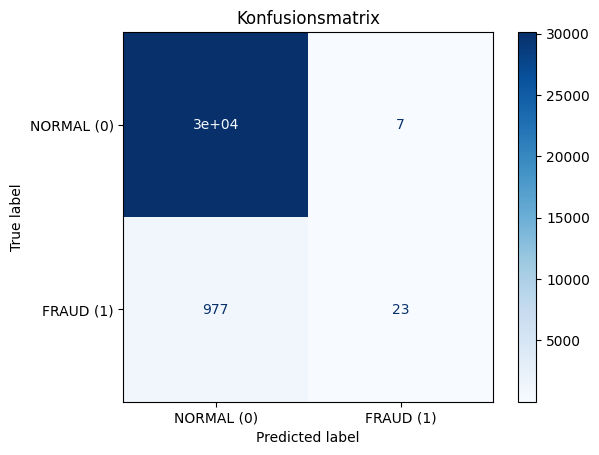


ROC-Kurve und AUC-Wert:
Area Under ROC Curve (AUC): 0.8221


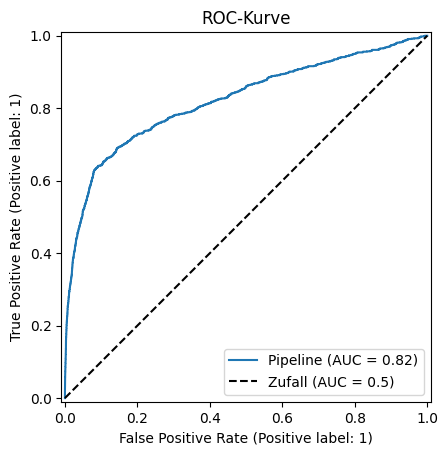

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# 1. Vorhersagen auf dem Testset
y_pred = model_pipeline.predict(X_test)

# Für ROC/AUC benötigen wir Wahrscheinlichkeits-Scores für die positive Klasse
# Stellen Sie sicher, dass Ihr Klassifikator 'predict_proba' unterstützt
try:
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    roc_auc_berechenbar = True
except AttributeError:
    print("Das Modell unterstützt 'predict_proba' nicht, ROC/AUC kann nicht berechnet werden.")
    roc_auc_berechenbar = False
except Exception as e:
    print(f"Fehler bei predict_proba: {e}")
    roc_auc_berechenbar = False

# 2. Klassifikationsbericht
# Definieren der Klassennamen basierend auf dem ursprünglichen Mapping {'FRAUD': 1, 'NORMAL': 0}
target_names = ['NORMAL (0)', 'FRAUD (1)'] 
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3. Konfusionsmatrix
print("\nKonfusionsmatrix:")
cm = confusion_matrix(y_test, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp_cm.plot(cmap=plt.cm.Blues)
plt.title("Konfusionsmatrix")
plt.show()

# 4. ROC-Kurve und AUC-Wert (falls Wahrscheinlichkeiten verfügbar sind)
if roc_auc_berechenbar:
    print("\nROC-Kurve und AUC-Wert:")
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"Area Under ROC Curve (AUC): {auc_score:.4f}")

    RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test)
    # Alternativ, falls from_estimator nicht direkt mit der Pipeline wie gewünscht funktioniert
    # oder man y_pred_proba verwenden möchte:
    # RocCurveDisplay.from_predictions(y_test, y_pred_proba)
    plt.title("ROC-Kurve")
    plt.plot([0, 1], [0, 1], 'k--', label='Zufall (AUC = 0.5)') # Referenzlinie für Zufall
    plt.legend()
    plt.show()
else:
    print("\nROC-Kurve und AUC-Wert konnten nicht erstellt werden.")
